Este archivo contiene las tareas realizadas en clase y, al final, la tarea en casa relacionada:

Con la integral:

\begin{align*}
    x &= \int_{t_0}^{t_1} \left[ u\ln\left(\frac{m_0}{m_0 - qt}\right) - gt \right] dt \\[7pt]
    x &= \int_{t_0}^{t_1} u\ln\left(\frac{m_0}{m_0 - qt}\right) dt - \int_{t_0}^{t_1}  gt ~dt \\[7pt]
    x &= u\int_{t_0}^{t_1} \ln\left(\frac{m_0}{m_0 - qt}\right) dt - \left.\frac{gt^2}{2} \right|_{t=t_0}^{t=t_1} \\[7pt]
    x &= u\left[\int_{t_0}^{t_1} \ln{m_0} ~dt - \int_{t_0}^{t_1} \ln{(m_0 - qt)} ~dt \right] - \left.\frac{gt^2}{2} \right|_{t=t_0}^{t=t_1} \\[7pt]
\end{align*}

Por otro lado:

\begin{align*}
    \int \ln{x} ~dx
\end{align*}

Con $u=\ln{x}$ y $dv=dx$ se llega a $du = dx/x$ y $v=x$. Así, integrando por partes:

\begin{align*}
    \int \ln{x} ~dx &= x\ln{x} - \int x \frac{dx}{x} = \int \ln{x} ~dx = x\ln{x} - \int dx = \int \ln{x} ~dx \\[7pt] 
    \int \ln{x} ~dx &= x\ln{x} - x
\end{align*}

Sabiendo esto, ahora con $u=m_0 - qt$, $du = -qdt$: 

\begin{align*}
    \int \ln{(m_0 - qt)} ~dt &= -\int \ln{u} ~\frac{du}{q} = -\frac{1}{q} (u\ln u - u) \\[7pt] 
    \int \ln{(m_0 - qt)} ~dt &= -\frac{1}{q} \left[ (m_0 -qt) \ln{(m_0 - qt)} - (m_0 - qt) \right] \\[7pt]
    \int \ln{(m_0 - qt)} ~dt &= -\frac{m_0 - qt}{q} \left[\ln{(m_0 - qt)} - 1 \right] \\[7pt]
    \int \ln{(m_0 - qt)} ~dt &= -\left(\frac{m_0}{q} - t\right) \left[\ln{(m_0 - qt)} - 1 \right] \\[7pt]
\end{align*}

Con esto:

\begin{align*}
    x &= u\left[\int_{t_0}^{t_1} \ln{m_0} ~dt - \int_{t_0}^{t_1} \ln{(m_0 - qt)} ~dt \right] - \left.\frac{gt^2}{2} \right|_{t=t_0}^{t=t_1} \\[7pt]
    x &= u\left\{(\ln{m_0})t + \left(\frac{m_0}{q} - t\right) \left[\ln{(m_0 - qt)} - 1 \right] - \frac{g}{2u}t^2 \right\}_{t=t_0}^{t=t_1}
\end{align*}

In [83]:
# # TAREA EN CLASE:

# Integración simbólica

import numpy as np

# Constantes

u  = 2000 # m/s
m0 = 140e3 # kg
q  = 2100 # kg/s
g = 9.81 # m/s^2

# Intervalo de integración

t0 = 8
t1 = 30

def pos(t):
    return u * ( np.log(m0)*t + (m0/q - t) * (np.log(m0 - q*t) - 1) ) - (g/2) * t**2

distancia = pos(t1) - pos(t0)
dist_real = distancia

print(f"La distancia vertical recorrida por el cohete entre t = {t0} s y t = {t1} s es: {distancia:.3f} m.")


La distancia vertical recorrida por el cohete entre t = 8 s y t = 30 s es: 11057.156 m.


In [84]:
# # TAREA EN CLASE:

# Integración Numérica: Regla del trapezoide (Singular)

def vel(t):
    return u * np.log(m0 / (m0 - q*t)) - g*t

def trapezoide_singular(f, a, b):
    return (b - a) * (f(a) + f(b)) / 2 

# A: 

dist_estim_singular = trapezoide_singular(vel, t0, t1)

print(f"A:\n  La estimación de la distancia vertical recorrida entre {t0} s y {t1} s es: {dist_estim_singular:.3f} m.")

# B:

err_abs = abs(dist_estim_singular - dist_real)

print(f"B: \n  El valor exacto es: {dist_real:.3f} m. \n  El error absoluto de esta estimación es de: {err_abs} m.")

# C:

eps = err_abs * 100 / dist_real

print(f"C: \n  El error relativo porcentual de esta estimación es de: {eps:.4f} %.")

A:
  La estimación de la distancia vertical recorrida entre 8 s y 30 s es: 11864.168 m.
B: 
  El valor exacto es: 11057.156 m. 
  El error absoluto de esta estimación es de: 807.0126547601812 m.
C: 
  El error relativo porcentual de esta estimación es de: 7.2986 %.


In [85]:
# # TAREA EN CLASE:

# Integración Numérica: Regla del trapezoide (Compuesta)

# A:

def vel(t):
    return u * np.log(m0 / (m0 - q*t)) - g*t

def trapezoide_compuesto(f, a, b, n):

    h = (b - a)/n
    suma = 0

    for i in range(1, n):
        suma += f(a + i*h)

    return h * ( f(a) + 2*suma + f(b)) / 2

dist_estim = trapezoide_compuesto(vel, t0, t1, n=2)

print(f"A: \n  La estimación de la distancia vertical entre {t0} s y {t1} s usando la regla \n  compuesta del trapezoide es: {dist_estim:.3f} m.")

# B:

err_abs = abs(dist_estim - dist_real)

print(f"B: \n  El valor exacto es: {dist_real:.3f} m. \n  El error absoluto de esta estimación es de: {err_abs} m.")

# C:

eps = err_abs * 100 / dist_real

print(f"C: \n  El error relativo porcentual de esta estimación es de: {eps:.4f} %.")




A: 
  La estimación de la distancia vertical entre 8 s y 30 s usando la regla 
  compuesta del trapezoide es: 11262.194 m.
B: 
  El valor exacto es: 11057.156 m. 
  El error absoluto de esta estimación es de: 205.03875817846892 m.
C: 
  El error relativo porcentual de esta estimación es de: 1.8544 %.


In [86]:
# # TAREA EN CLASE:

# Integración Numérica: Simpson 1/3

def f(x):
    return 5 * x * np.exp(-2*x)  

def int_analitica(x):
    return - (5/4) * (2*x + 1) * np.exp(-2*x) 

x0 = 1.3
x1 = 0.1

def simpson_13(f, a, b):

    h = (b - a)/2

    return h * ( f(a) + 4 * f((a + b)/2) + f(b)) / 3

# A:

est_simpson = simpson_13(f, x0, x1)
print(f"A: \n  La estimación de la integral con el método Simpson 1/3 es: {est_simpson:.6f}.")

# B:

val_real = int_analitica(x1) - int_analitica(x0)
err_abs = abs(val_real - est_simpson)
print(f"B: \n  El valor exacto de la integral es: {val_real:.6f}. \n  El error absoluto de esta estimación es de: {err_abs:.6f}.")

# C:

eps = err_abs * 100 / abs(val_real)
print(f"C: \n  El error relativo porcentual de la estimación es de: {eps:.6f} %.")


A: 
  La estimación de la integral con el método Simpson 1/3 es: -0.868900.
B: 
  El valor exacto de la integral es: -0.893865. 
  El error absoluto de esta estimación es de: 0.024965.
C: 
  El error relativo porcentual de la estimación es de: 2.792905 %.


n  Distancia [m]  Error absoluto [m]  Error relativo [%]  
-------------------------------------------------------
1  11864.168      807.013             7.299               
2  11262.194      205.039             1.854               
3  11148.579      91.424              0.827               
4  11108.641      51.485              0.466               
5  11090.124      32.968              0.298               
6  11080.057      22.901              0.207               
7  11073.984      16.828              0.152               
8  11070.041      12.886              0.117               


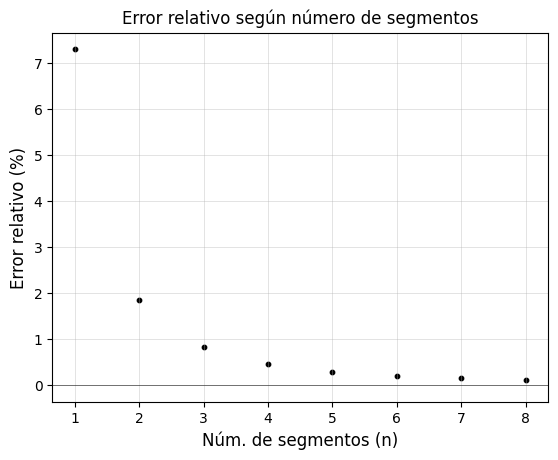

In [87]:
# # TAREA EN CASA:

# Esta tarea se enfoca en contrastar los resultados para la regla del trapezoide con distinto número de segmentos "n":

import matplotlib.pyplot as plt

n = np.linspace(1, 8, 8, dtype=int) 

print(f"{'n':<3}" f"{'Distancia [m]':<15}" f"{'Error absoluto [m]':<20}" f"{'Error relativo [%]':<20}")
print("-"*55)

plt.figure()

plt.xlabel("Núm. de segmentos (n)", fontsize=12)
plt.ylabel("Error relativo (%)", fontsize=12)
plt.axhline(0, linewidth=0.5, color='k', alpha=0.7)
plt.grid(linewidth=0.5, alpha=0.5)
plt.title("Error relativo según número de segmentos")

for i in range(8):
    distance = trapezoide_compuesto(vel, t0, t1, n[i])
    error_abs = abs(dist_real - distance)
    error_rel = 100 * error_abs / dist_real

    print(
        f"{n[i]:<3}"
        f"{distance :<15.3f}"
        f"{error_abs:<20.3f}"
        f"{error_rel:<20.3f}"
    )

    plt.scatter(n[i], error_rel, color='k', s=10)
